<a href="https://colab.research.google.com/github/Omarr127/Day1_Solship/blob/main/Notebook2_Forecaster_DailyWindow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔋 Energy AI Hackathon 2026 — Notebook 2: Forecasting & Results
**Solship | Zewail City of Science and Technology**

---
### Pipeline
1. Install & Import
2. Load 2024 Features
3. Train / Validation Split (Jan–Sep train | Oct–Dec val)
4. XGBoost — Train & Validate
5. LightGBM — Train & Validate
6. Ensemble — Validate
7. Validation Summary & Plot
8. Retrain on Full 2024
9. Test on April & September 2025
10. Final Results & Save Forecast
---

## 1. Install & Import

In [1]:
!pip install xgboost lightgbm scikit-learn --quiet

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import lightgbm as lgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings('ignore')
pd.set_option('display.float_format', '{:.4f}'.format)
plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print('✅ All libraries imported')

✅ All libraries imported


## 2. Load 2024 Features

In [3]:
# ── Load feature file & feature list ──────────────────────────
df = pd.read_csv('/content/features_2024.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

with open('/content/feature_cols.json', 'r') as f:
    FEATURE_COLS = json.load(f)

# Keep only features that exist in the dataframe
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
TARGET = 'load_kw'

print(f'Shape         : {df.shape}')
print(f'Features      : {len(FEATURE_COLS)}')
print(f'Date range    : {df.timestamp.min()} → {df.timestamp.max()}')
print(f'Target mean   : {df[TARGET].mean():.4f} kW')
print(f'Target std    : {df[TARGET].std():.4f} kW')
print()
print('Feature list:')
for i, c in enumerate(FEATURE_COLS, 1):
    print(f'  {i:2d}. {c}')

Shape         : (35132, 80)
Features      : 73
Date range    : 2024-01-01 00:00:00 → 2024-12-31 23:45:00
Target mean   : 1.4886 kW
Target std    : 1.2595 kW

Feature list:
   1. pv_kw
   2. sell_price
   3. buy_price
   4. temp_c
   5. humidity_pct
   6. cloud_cover_pct
   7. precipitation_mm
   8. solar_radiation_wm2
   9. windspeed_ms
  10. temp_lag_4h
  11. temp_lag_24h
  12. temp_ewma_6h
  13. temp_x_hour
  14. is_hot_day
  15. is_cold_day
  16. hour
  17. minute
  18. quarter_of_hour
  19. step_of_day
  20. dow
  21. month
  22. day_of_year
  23. week_of_year
  24. quarter
  25. is_weekend
  26. is_holiday
  27. is_working_day
  28. days_until_holiday
  29. days_after_holiday
  30. sin_hour
  31. cos_hour
  32. sin_dow
  33. cos_dow
  34. sin_month
  35. cos_month
  36. sin_doy
  37. cos_doy
  38. band_int
  39. next_band_int
  40. is_band_changing_next
  41. mins_until_band_change
  42. sell_price_lag1
  43. price_spread
  44. is_export_profitable
  45. is_solar_hour
  46. pv_lag

## 3. Train / Validation Split

In [4]:
# ── Train: Jan–Sep 2024 | Validation: Oct–Dec 2024 ────────────
train_mask = df['timestamp'] < '2024-10-01'
val_mask   = df['timestamp'] >= '2024-10-01'

X_train = df.loc[train_mask, FEATURE_COLS]
y_train = df.loc[train_mask, TARGET]
X_val   = df.loc[val_mask,   FEATURE_COLS]
y_val   = df.loc[val_mask,   TARGET]

print(f'Train : {len(X_train)} rows  ({df.loc[train_mask,"timestamp"].min().date()} → {df.loc[train_mask,"timestamp"].max().date()})')
print(f'Val   : {len(X_val)} rows  ({df.loc[val_mask,"timestamp"].min().date()} → {df.loc[val_mask,"timestamp"].max().date()})')
print(f'Features: {len(FEATURE_COLS)}')
print(f'Nulls in X_train: {X_train.isnull().sum().sum()}')
print(f'Nulls in X_val  : {X_val.isnull().sum().sum()}')

Train : 26300 rows  (2024-01-01 → 2024-09-30)
Val   : 8832 rows  (2024-10-01 → 2024-12-31)
Features: 73
Nulls in X_train: 0
Nulls in X_val  : 0


## 4. Metric Helper

In [5]:
def evaluate(y_true, y_pred, model_name='Model'):
    """Compute RMSE, MAE, NRMSE and print results."""
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    nrmse = rmse / y_true.mean() * 100
    print(f'┌─ {model_name} ─────────────────────')
    print(f'│  RMSE  : {rmse:.4f} kW')
    print(f'│  MAE   : {mae:.4f} kW')
    print(f'│  NRMSE : {nrmse:.4f} %')
    print(f'└────────────────────────────────────')
    return {'model': model_name, 'RMSE': rmse, 'MAE': mae, 'NRMSE': nrmse}

## 5. XGBoost — Train & Validate

In [6]:
# ══════════════════════════════════════════════════════════════
# MODEL 1 — XGBoost
# lr=0.02, depth=8, n_estimators=2000, early stopping on val
# ══════════════════════════════════════════════════════════════

xgb_model = XGBRegressor(
    n_estimators          = 2000,
    learning_rate         = 0.02,
    max_depth             = 8,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    random_state          = 42,
    n_jobs                = -1,
    early_stopping_rounds = 50,
    eval_metric           = 'rmse',
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

xgb_val_pred = np.clip(xgb_model.predict(X_val), 0, None)
print(f'\nBest iteration: {xgb_model.best_iteration}')

[0]	validation_0-rmse:1.26831
[100]	validation_0-rmse:0.20136
[200]	validation_0-rmse:0.07794
[300]	validation_0-rmse:0.06706
[400]	validation_0-rmse:0.06393
[500]	validation_0-rmse:0.06272
[600]	validation_0-rmse:0.06227
[700]	validation_0-rmse:0.06195
[800]	validation_0-rmse:0.06177
[900]	validation_0-rmse:0.06162
[1000]	validation_0-rmse:0.06153
[1100]	validation_0-rmse:0.06145
[1200]	validation_0-rmse:0.06142
[1300]	validation_0-rmse:0.06137
[1400]	validation_0-rmse:0.06135
[1500]	validation_0-rmse:0.06133
[1600]	validation_0-rmse:0.06131
[1700]	validation_0-rmse:0.06129
[1800]	validation_0-rmse:0.06128
[1900]	validation_0-rmse:0.06128
[1999]	validation_0-rmse:0.06126

Best iteration: 1988


In [7]:
# ── XGBoost Validation Metrics ─────────────────────────────────
print('=== XGBoost — Validation Results ===')
xgb_metrics = evaluate(y_val, xgb_val_pred, 'XGBoost')

=== XGBoost — Validation Results ===
┌─ XGBoost ─────────────────────
│  RMSE  : 0.0613 kW
│  MAE   : 0.0177 kW
│  NRMSE : 3.8310 %
└────────────────────────────────────


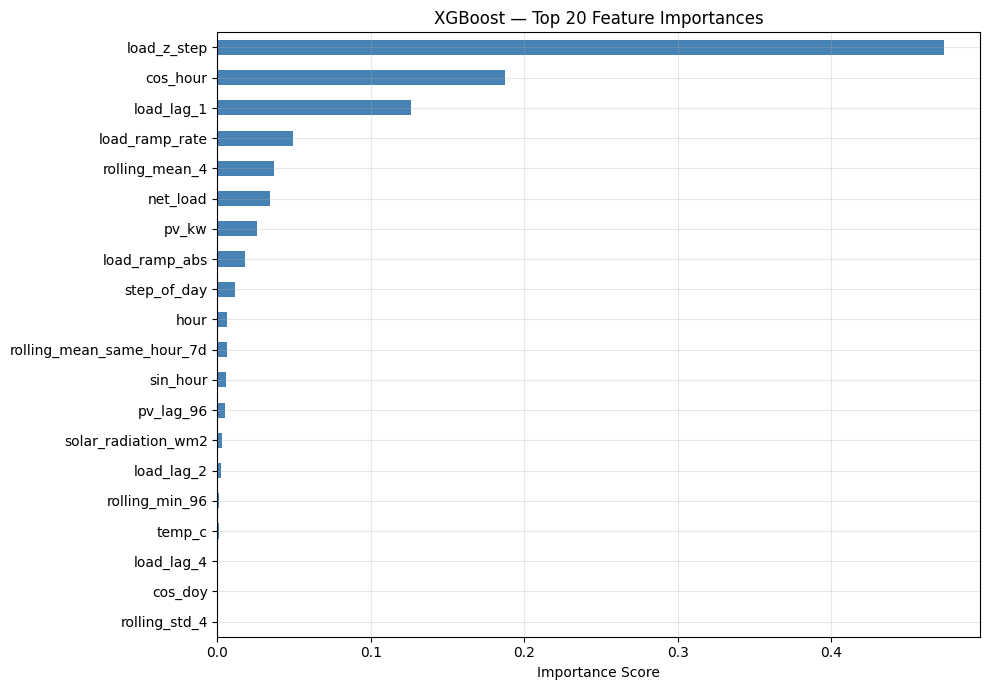

In [8]:
# ── XGBoost Feature Importance ─────────────────────────────────
trained_features = xgb_model.get_booster().feature_names
importance_xgb   = pd.Series(xgb_model.feature_importances_, index=trained_features)
top20_xgb        = importance_xgb.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_xgb.plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('XGBoost — Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('xgb_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. LightGBM — Train & Validate

In [38]:
lgbm_model = LGBMRegressor(
    n_estimators      = 2000,
    learning_rate     = 0.02,
    max_depth         = 8,
    num_leaves        = 127,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)

lgbm_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    eval_names=['train', 'val'],
    eval_metric='rmse',
    callbacks=[
        lgb.early_stopping(50, verbose=False),
        lgb.log_evaluation(100)
    ]
)

lgbm_val_pred = np.clip(lgbm_model.predict(X_val), 0, None)

[100]	train's rmse: 0.183906	train's l2: 0.0338214	val's rmse: 0.201153	val's l2: 0.0404625
[200]	train's rmse: 0.0458091	train's l2: 0.00209847	val's rmse: 0.0751637	val's l2: 0.00564958
[300]	train's rmse: 0.0302357	train's l2: 0.000914199	val's rmse: 0.0632975	val's l2: 0.00400658
[400]	train's rmse: 0.0264875	train's l2: 0.000701589	val's rmse: 0.0608442	val's l2: 0.00370201
[500]	train's rmse: 0.0247529	train's l2: 0.000612706	val's rmse: 0.0600368	val's l2: 0.00360442
[600]	train's rmse: 0.02303	train's l2: 0.000530383	val's rmse: 0.0596335	val's l2: 0.00355616
[700]	train's rmse: 0.021451	train's l2: 0.000460145	val's rmse: 0.05943	val's l2: 0.00353192
[800]	train's rmse: 0.020173	train's l2: 0.000406951	val's rmse: 0.0592147	val's l2: 0.00350638
[900]	train's rmse: 0.0190852	train's l2: 0.000364245	val's rmse: 0.0589298	val's l2: 0.00347272
[1000]	train's rmse: 0.018061	train's l2: 0.000326199	val's rmse: 0.0587251	val's l2: 0.00344864
[1100]	train's rmse: 0.0171741	train's l2:

=== LightGBM — Validation Results ===
┌─ LightGBM ─────────────────────
│  RMSE  : 0.0569 kW
│  MAE   : 0.0185 kW
│  NRMSE : 3.5589 %
└────────────────────────────────────
dict_keys(['train', 'val'])


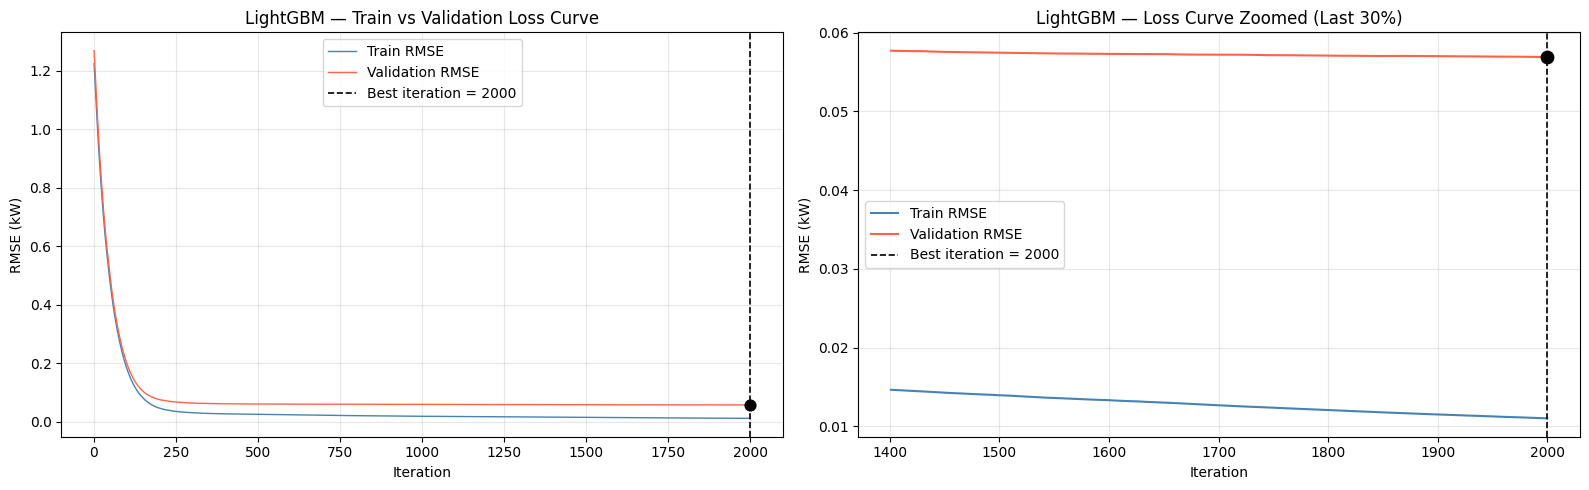

Best iteration  : 2000
Best train RMSE : 0.0110 kW
Best val RMSE   : 0.0569 kW
Overfit gap     : 0.0459 kW


In [39]:
# ── LightGBM Validation Results ────────────────────────────────
print('=== LightGBM — Validation Results ===')
lgbm_metrics = evaluate(y_val, lgbm_val_pred, 'LightGBM')


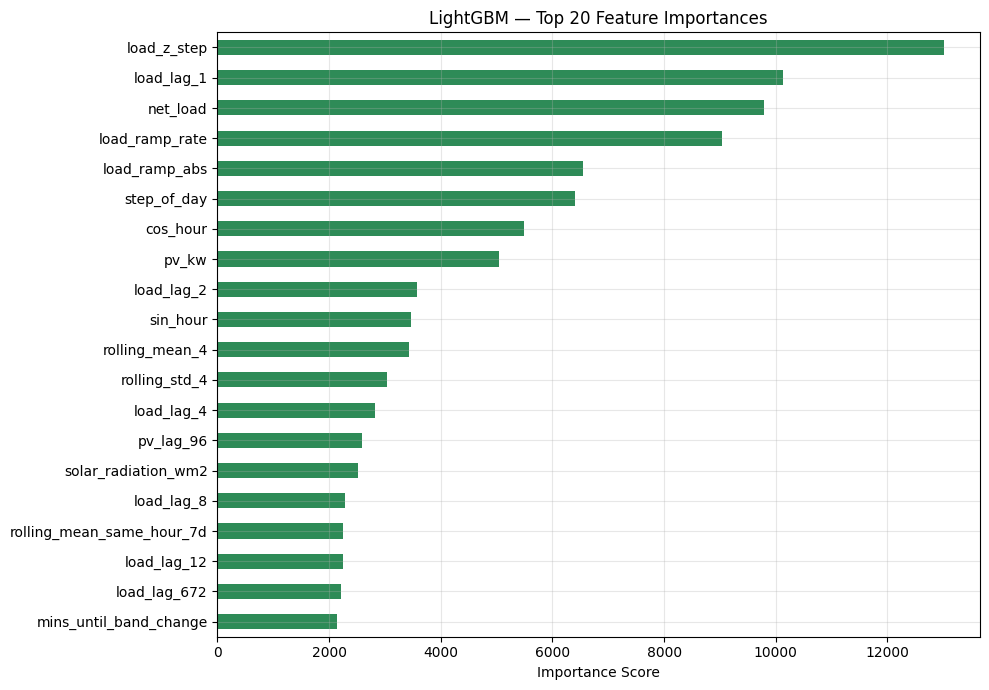

In [11]:
# ── LightGBM Feature Importance ────────────────────────────────
importance_lgbm = pd.Series(lgbm_model.feature_importances_, index=FEATURE_COLS)
top20_lgbm      = importance_lgbm.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 7))
top20_lgbm.plot(kind='barh', ax=ax, color='seagreen')
ax.invert_yaxis()
ax.set_title('LightGBM — Top 20 Feature Importances')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.savefig('lgbm_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()

dict_keys(['train', 'val'])


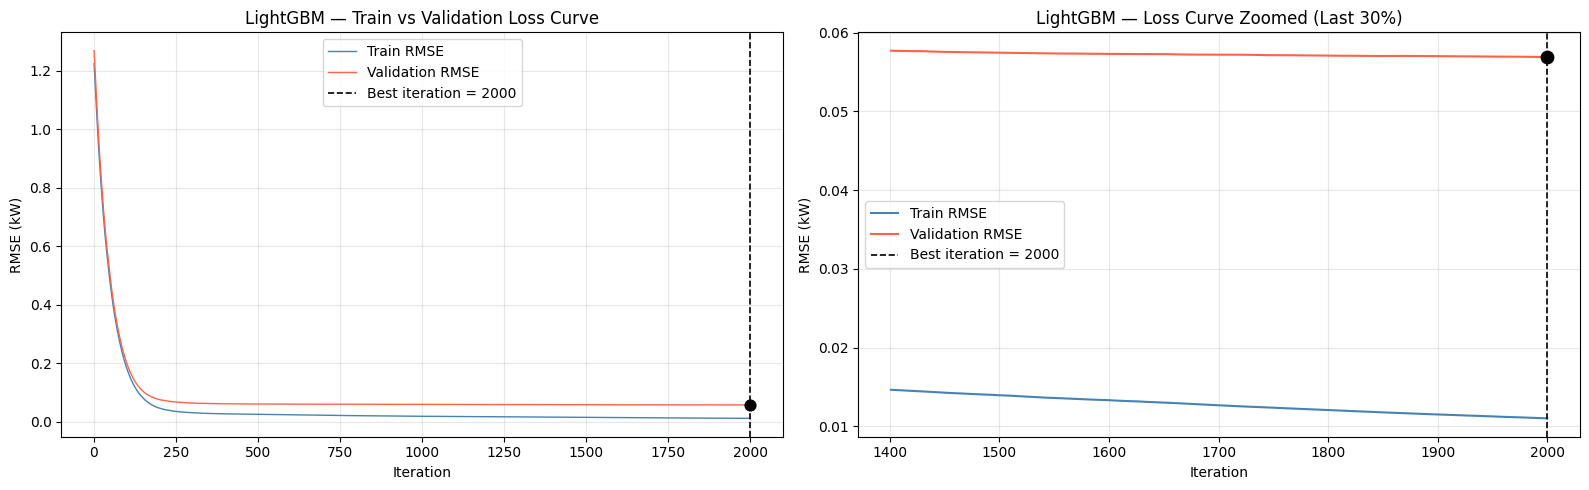

Best iteration  : 2000
Best train RMSE : 0.0110 kW
Best val RMSE   : 0.0569 kW
Overfit gap     : 0.0459 kW


In [40]:
# loss curve to ensure no overfitting
evals_result = lgbm_model.evals_result_
print(evals_result.keys())

train_loss = evals_result['train']['rmse']
val_loss   = evals_result['val']['rmse']
epochs     = list(range(1, len(train_loss) + 1))
best_iter  = lgbm_model.best_iteration_

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(epochs, train_loss, label='Train RMSE',      color='steelblue', linewidth=1.0)
axes[0].plot(epochs, val_loss,   label='Validation RMSE', color='tomato',    linewidth=1.0)
axes[0].axvline(best_iter, color='black', linestyle='--', linewidth=1.2,
                label=f'Best iteration = {best_iter}')
axes[0].scatter([best_iter], [val_loss[best_iter-1]], color='black', s=60, zorder=5)
axes[0].set_title('LightGBM — Train vs Validation Loss Curve')
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('RMSE (kW)')
axes[0].legend()

start = int(len(train_loss) * 0.7)
axes[1].plot(epochs[start:], train_loss[start:], label='Train RMSE',      color='steelblue', linewidth=1.5)
axes[1].plot(epochs[start:], val_loss[start:],   label='Validation RMSE', color='tomato',    linewidth=1.5)
axes[1].axvline(best_iter, color='black', linestyle='--', linewidth=1.2,
                label=f'Best iteration = {best_iter}')
axes[1].scatter([best_iter], [val_loss[best_iter-1]], color='black', s=80, zorder=5)
axes[1].set_title('LightGBM — Loss Curve Zoomed (Last 30%)')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('RMSE (kW)')
axes[1].legend()

plt.tight_layout()
plt.savefig('lgbm_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Best iteration  : {best_iter}')
print(f'Best train RMSE : {train_loss[best_iter-1]:.4f} kW')
print(f'Best val RMSE   : {val_loss[best_iter-1]:.4f} kW')
print(f'Overfit gap     : {val_loss[best_iter-1] - train_loss[best_iter-1]:.4f} kW')



## 9. Retrain on Full 2024

In [15]:
# ── Load 2025 test features ─────────────────────────────────────
df_2025 = pd.read_csv('/content/features_2025.csv')
df_2025['timestamp'] = pd.to_datetime(df_2025['timestamp'])

FEATURE_COLS_TEST = [c for c in FEATURE_COLS if c in df_2025.columns]
missing = [c for c in FEATURE_COLS if c not in df_2025.columns]

print(f'2025 rows          : {len(df_2025)}')
print(f'Features available : {len(FEATURE_COLS_TEST)}')
print(f'Missing features   : {missing}')
print(f'Nulls in 2025      : {df_2025[FEATURE_COLS_TEST].isnull().sum().sum()}')

# April and September masks
mask_apr = df_2025['timestamp'].dt.month == 4
mask_sep = df_2025['timestamp'].dt.month == 9
print(f'\nApril rows     : {mask_apr.sum()}')
print(f'September rows : {mask_sep.sum()}')

2025 rows          : 34941
Features available : 73
Missing features   : []
Nulls in 2025      : 0

April rows     : 2880
September rows : 2880


In [42]:
# ── Retrain both models on FULL 2024 ──────────────────────────
# Use best iterations found during validation
X_full = df[FEATURE_COLS_TEST]
y_full = df[TARGET]
X_test = df_2025[FEATURE_COLS_TEST]
y_test = df_2025[TARGET]

print(f'X_full shape : {X_full.shape}')
print(f'X_test shape : {X_test.shape}')


# LightGBM final — use best_iteration from validation
lgbm_final = LGBMRegressor(
    n_estimators      = lgbm_model.best_iteration_,
    learning_rate     = 0.02,
    max_depth         = 8,
    num_leaves        = 127,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
lgbm_final.fit(X_full, y_full)
print(f'✅ LightGBM final trained (n_estimators={lgbm_model.best_iteration_})')

# Predictions on full 2025

lgbm_test_pred = np.clip(lgbm_final.predict(X_test), 0, None)

print('\n✅ Predictions generated for full 2025')

X_full shape : (35132, 73)
X_test shape : (34941, 73)
✅ LightGBM final trained (n_estimators=2000)

✅ Predictions generated for full 2025


## 10. Test on April & September 2025 using LightGbm

In [22]:
# ── Retrain LightGBM on FULL 2024 ─────────────────────────────
X_full = df[FEATURE_COLS_TEST]
y_full = df[TARGET]

# Extract only April and September from 2025
df_apr = df_2025[mask_apr].reset_index(drop=True)
df_sep = df_2025[mask_sep].reset_index(drop=True)

X_apr = df_apr[FEATURE_COLS_TEST]
y_apr = df_apr[TARGET]

X_sep = df_sep[FEATURE_COLS_TEST]
y_sep = df_sep[TARGET]

print(f'X_full shape : {X_full.shape}')
print(f'X_apr shape  : {X_apr.shape}')
print(f'X_sep shape  : {X_sep.shape}')

# LightGBM final — use best_iteration from validation
lgbm_final = LGBMRegressor(
    n_estimators      = lgbm_model.best_iteration_,
    learning_rate     = 0.02,
    max_depth         = 8,
    num_leaves        = 127,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1,
)
lgbm_final.fit(X_full, y_full)
print(f'✅ LightGBM retrained (n_estimators={lgbm_model.best_iteration_})')

# Predict only April and September
lgbm_apr = np.clip(lgbm_final.predict(X_apr), 0, None)
lgbm_sep = np.clip(lgbm_final.predict(X_sep), 0, None)

print('✅ Predictions generated for April and September only')

X_full shape : (35132, 73)
X_apr shape  : (2880, 73)
X_sep shape  : (2880, 73)
✅ LightGBM retrained (n_estimators=2000)
✅ Predictions generated for April and September only


In [43]:
# April results
print('=' * 50)
print('APRIL 2025 — TEST RESULTS')
print('=' * 50)
lgbm_apr_metrics = evaluate(y_apr, lgbm_apr, 'LightGBM — April')

# September results
print('=' * 50)
print('SEPTEMBER 2025 — TEST RESULTS')
print('=' * 50)
lgbm_sep_metrics = evaluate(y_sep, lgbm_sep, 'LightGBM — September')

APRIL 2025 — TEST RESULTS
┌─ LightGBM — April ─────────────────────
│  RMSE  : 0.0746 kW
│  MAE   : 0.0381 kW
│  NRMSE : 7.7404 %
└────────────────────────────────────
SEPTEMBER 2025 — TEST RESULTS
┌─ LightGBM — September ─────────────────────
│  RMSE  : 0.0635 kW
│  MAE   : 0.0331 kW
│  NRMSE : 7.5726 %
└────────────────────────────────────


Graphs Verifying

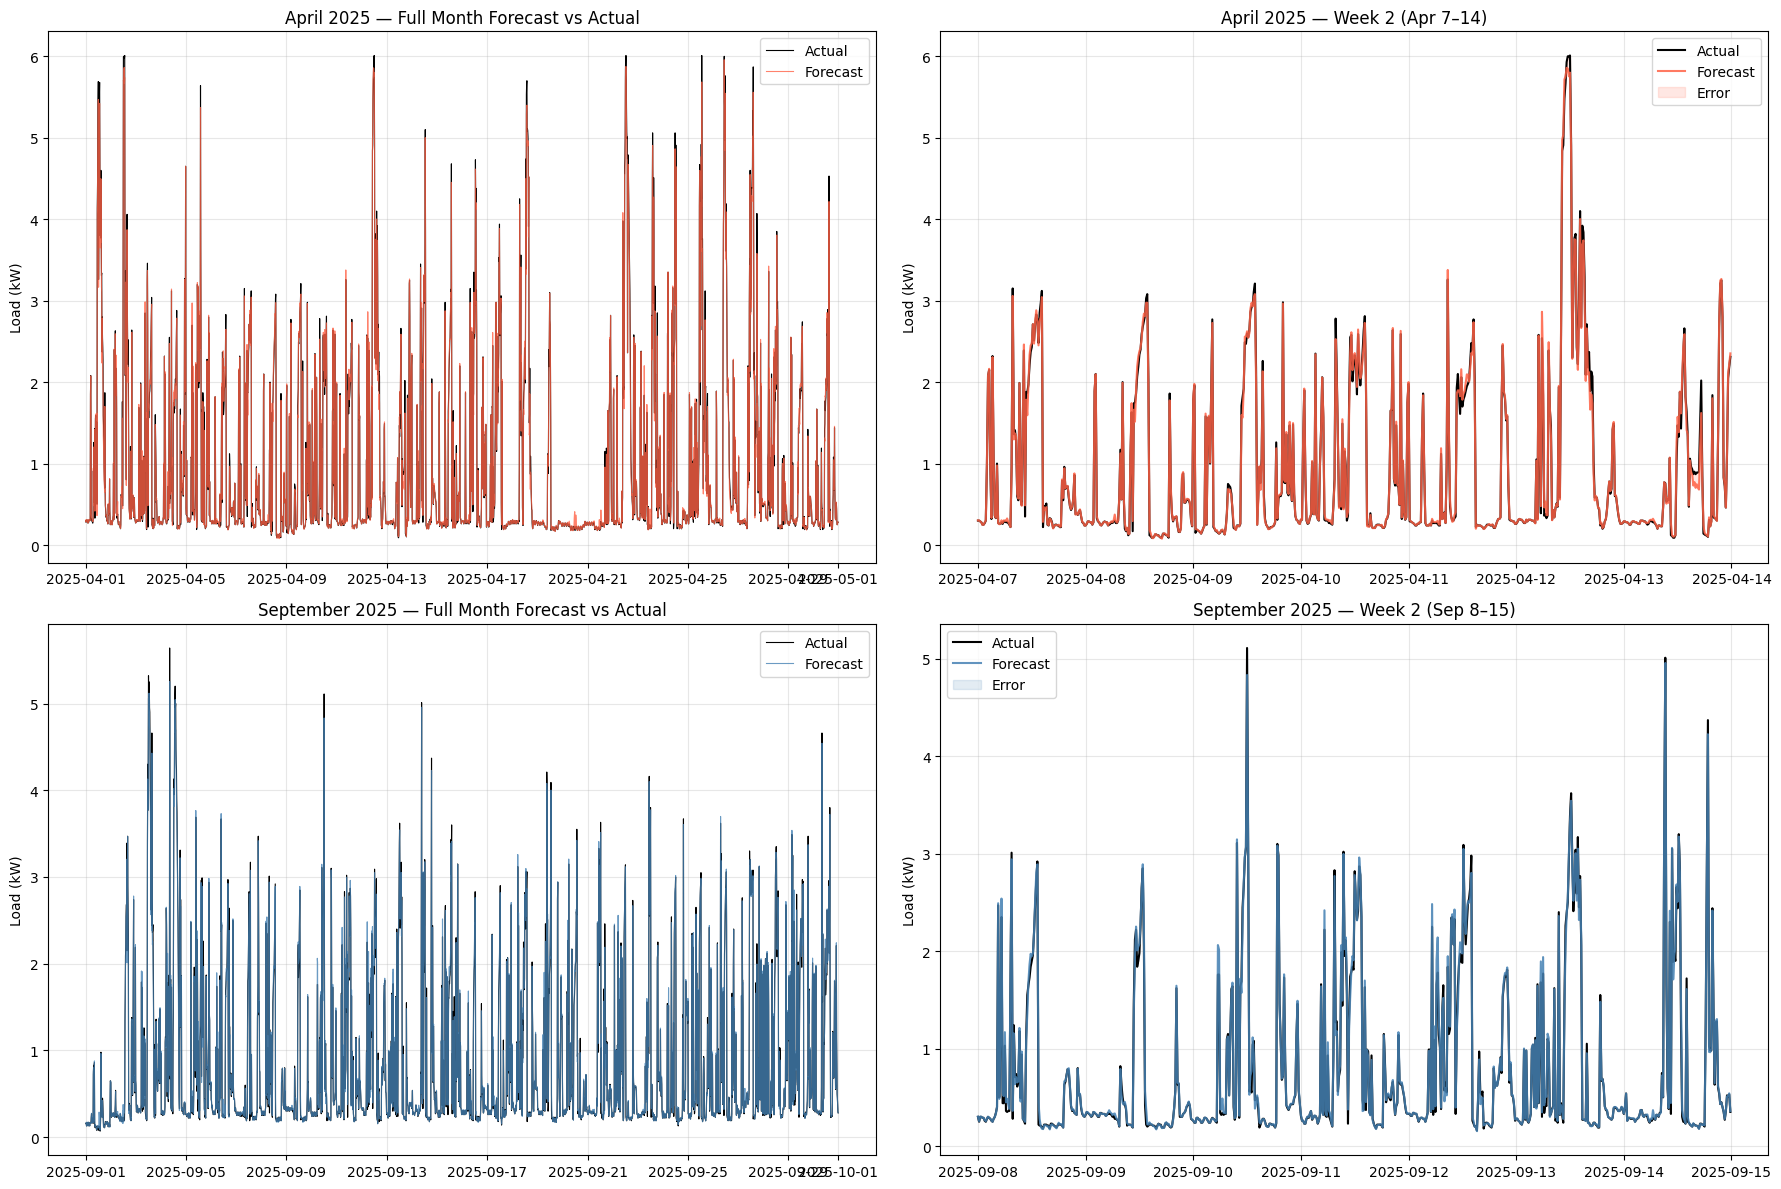

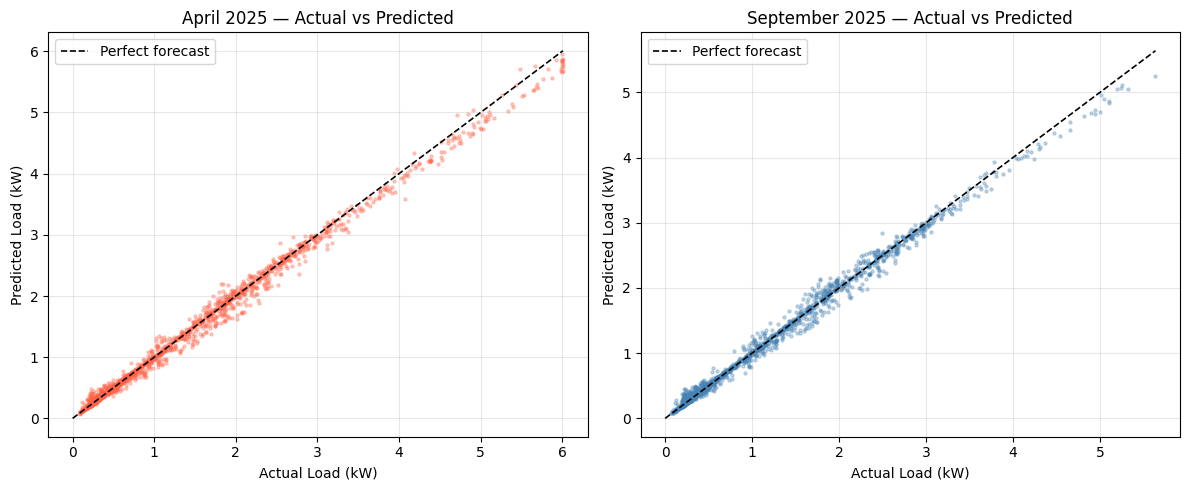

In [44]:
# ── Forecast vs Actual — April & September 2025 ───────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# ── April: Full Month ──────────────────────────────────────────
ts_apr = df_apr['timestamp']
axes[0,0].plot(ts_apr, y_apr.values,  label='Actual',   color='black',  linewidth=0.8)
axes[0,0].plot(ts_apr, lgbm_apr,      label='Forecast', color='tomato', linewidth=0.8, alpha=0.8)
axes[0,0].set_title('April 2025 — Full Month Forecast vs Actual')
axes[0,0].set_ylabel('Load (kW)')
axes[0,0].legend()

# ── April: Sample Week ─────────────────────────────────────────
mask_week_apr = ((ts_apr >= '2025-04-07') & (ts_apr < '2025-04-14')).values
axes[0,1].plot(ts_apr[mask_week_apr], y_apr.values[mask_week_apr],
               label='Actual',   color='black',  linewidth=1.5)
axes[0,1].plot(ts_apr[mask_week_apr], lgbm_apr[mask_week_apr],
               label='Forecast', color='tomato', linewidth=1.5, alpha=0.85)
axes[0,1].fill_between(ts_apr[mask_week_apr],
                        y_apr.values[mask_week_apr], lgbm_apr[mask_week_apr],
                        alpha=0.15, color='tomato', label='Error')
axes[0,1].set_title('April 2025 — Week 2 (Apr 7–14)')
axes[0,1].set_ylabel('Load (kW)')
axes[0,1].legend()

# ── September: Full Month ──────────────────────────────────────
ts_sep = df_sep['timestamp']
axes[1,0].plot(ts_sep, y_sep.values,  label='Actual',   color='black',     linewidth=0.8)
axes[1,0].plot(ts_sep, lgbm_sep,      label='Forecast', color='steelblue', linewidth=0.8, alpha=0.8)
axes[1,0].set_title('September 2025 — Full Month Forecast vs Actual')
axes[1,0].set_ylabel('Load (kW)')
axes[1,0].legend()

# ── September: Sample Week ─────────────────────────────────────
mask_week_sep = ((ts_sep >= '2025-09-08') & (ts_sep < '2025-09-15')).values
axes[1,1].plot(ts_sep[mask_week_sep], y_sep.values[mask_week_sep],
               label='Actual',   color='black',     linewidth=1.5)
axes[1,1].plot(ts_sep[mask_week_sep], lgbm_sep[mask_week_sep],
               label='Forecast', color='steelblue', linewidth=1.5, alpha=0.85)
axes[1,1].fill_between(ts_sep[mask_week_sep],
                        y_sep.values[mask_week_sep], lgbm_sep[mask_week_sep],
                        alpha=0.15, color='steelblue', label='Error')
axes[1,1].set_title('September 2025 — Week 2 (Sep 8–15)')
axes[1,1].set_ylabel('Load (kW)')
axes[1,1].legend()

plt.tight_layout()
plt.savefig('forecast_vs_actual_apr_sep.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Scatter Plot: Actual vs Predicted ─────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_apr.values, lgbm_apr, alpha=0.3, s=5, color='tomato')
axes[0].plot([0, y_apr.max()], [0, y_apr.max()], 'k--', linewidth=1.2, label='Perfect forecast')
axes[0].set_xlabel('Actual Load (kW)')
axes[0].set_ylabel('Predicted Load (kW)')
axes[0].set_title('April 2025 — Actual vs Predicted')
axes[0].legend()

axes[1].scatter(y_sep.values, lgbm_sep, alpha=0.3, s=5, color='steelblue')
axes[1].plot([0, y_sep.max()], [0, y_sep.max()], 'k--', linewidth=1.2, label='Perfect forecast')
axes[1].set_xlabel('Actual Load (kW)')
axes[1].set_ylabel('Predicted Load (kW)')
axes[1].set_title('September 2025 — Actual vs Predicted')
axes[1].legend()

plt.tight_layout()
plt.savefig('scatter_actual_vs_predicted.png', dpi=120, bbox_inches='tight')
plt.show()